# CNN_SignMNIST_Pretrained_DenseNet

### Sign MNIST를 PreTrained DenseNet을 이용한 CNN으로 구현하라
### (Colab을 사용하는 경우 "files/sign_mnist" 폴더를 "내 드라이브/files/"에 복사)

>### Load modules

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0


> ### Load Data

In [ ]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [ ]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_12_CNN_SignMNIST_Pretrained_DenseNet/files/sign_mnist/'
else :
  files_path = '../files/sign_mnist/'

In [ ]:
# csv에서 이미지 읽기
import csv
def get_data(filename):
    with open(filename) as training_file:
        reader = csv.reader(training_file, delimiter=',')
        imgs = []
        labels = []

        next(reader, None)

        for row in reader:
            label = row[0]
            data = row[1:]
            img = np.array(data).reshape((28, 28))

            imgs.append(img)
            labels.append(label)

        images = np.array(imgs).astype(np.float32)
        labels = np.array(labels).astype(np.float32)
    return images, labels

training_data, training_labels = get_data(files_path + 'sign_mnist_train/sign_mnist_train.csv')
testing_data, testing_labels = get_data(files_path + 'sign_mnist_test/sign_mnist_test.csv')

In [ ]:
print(training_data.shape)
print(training_labels.shape)
print(training_labels[:10])
print(testing_data.shape)
print(testing_labels.shape)
print(testing_labels[:10])

(27455, 28, 28)
(27455,)
[ 3.  6.  2.  2. 13. 16.  8. 22.  3.  3.]
(7172, 28, 28)
(7172,)
[ 6.  5. 10.  0.  3. 21. 10. 14.  3.  7.]


In [ ]:
# Dataset 크기 줄이기
training_data = training_data[::10]
training_labels = training_labels[::10]
testing_data = testing_data[::10]
testing_labels = testing_labels[::10]

In [ ]:
# 1. train_data, train_labels, test_data, test_labels 준비 -> train_data와 test_data는 채널 3개로 변경해야 함
train_data = np.zeros(training_data.shape + (3,))

train_data[:,:,:,0] = training_data
train_data[:,:,:,1] = training_data
train_data[:,:,:,2] = training_data

test_data = np.zeros(testing_data.shape + (3,))
test_data[:,:,:,0] = testing_data
test_data[:,:,:,1] = testing_data
test_data[:,:,:,2] = testing_data

train_labels = training_labels
test_labels = testing_labels

print(train_data.shape)
print(train_labels.shape)
print(train_labels[:10])
print(test_data.shape)
print(test_labels.shape)
print(test_labels[:10])

(2746, 28, 28, 3)
(2746,)
[ 3. 18. 18.  1. 11.  0.  4. 12. 16. 21.]
(718, 28, 28, 3)
(718,)
[ 6.  8.  2.  7. 15. 20. 10. 20. 17.  2.]


In [ ]:
# 2. 전처리: 0 ~ 1로 변환
train_data = train_data / 255.0
test_data = test_data / 255.0

In [ ]:
# 3. 64*64로 키우기 -> tf.image.resize()를 활용하라
IMG_SIZE = 64
train_data = tf.image.resize(train_data, (IMG_SIZE, IMG_SIZE))
test_data = tf.image.resize(test_data, (IMG_SIZE, IMG_SIZE))
print(train_data.shape, test_data.shape)

(2746, 64, 64, 3) (718, 64, 64, 3)


In [ ]:
# 4. Keras Model 정의, Model summary
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(tf.keras.applications.densenet.DenseNet121(
    # 경로가 막혀 자동 다운로드가 안 될 경우 아래 링크를 클릭하여 파일 다운로드 받고,
    # 그 경로를 아래 weights에 설정
    # weights='../files/densenet121.h5',
    weights="imagenet",
    include_top=False,    # dense layer 이후는 제외
    ))

# Dense layers
model.add(tf.keras.layers.Flatten(name='flatten'))
model.add(tf.keras.layers.Dense(1024, name='dense_1024'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation('relu'))
model.add(tf.keras.layers.Dense(26, activation='softmax', name='dense_10'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 2, 2, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1024 (Dense)                   │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 26)                  │          26,650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,263,578 (42.97 MB)

 Trainable params: 11,177,882 (42.64 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [ ]:
# 5. Model compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 6. Make_Result_Plot() 함수 정의
def Make_Result_Plot(suptitle:str, data:np.ndarray, label:np.ndarray, y_max:np.ndarray):
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        ax_result[idx//5,idx%5].imshow(data[idx])
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(idx, label[idx], y_max[idx]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


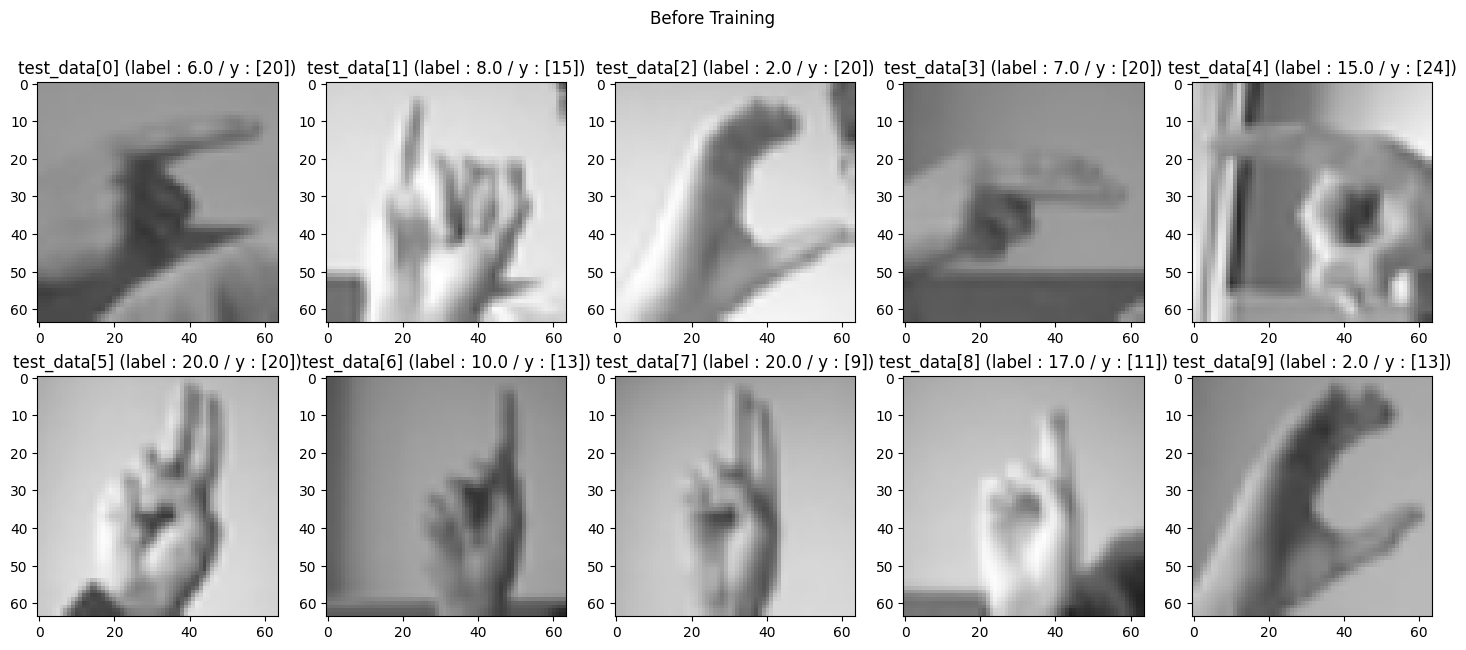

In [ ]:
# 7. 학습 전 상황 그리기
y_out = model.predict(test_data[:10])
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

In [ ]:
# 8. Model fit

In [ ]:
%%time
history = model.fit(train_data, train_labels, epochs=10,
                 validation_data=(test_data, test_labels) )

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.5263 - loss: 1.8809 - val_accuracy: 0.4373 - val_loss: 4.6375
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9279 - loss: 0.2530 - val_accuracy: 0.5390 - val_loss: 4.4561
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9643 - loss: 0.1048 - val_accuracy: 0.8997 - val_loss: 0.4550
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9641 - loss: 0.1218 - val_accuracy: 0.6685 - val_loss: 1.7723
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9812 - loss: 0.0806 - val_accuracy: 0.8858 - val_loss: 0.4380
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9787 - loss: 0.0780 - val_accuracy: 0.8844 - val_loss: 0.7687
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9798 - loss: 0.0595 - val_accuracy: 0.9067 - val_loss: 0.3666
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9840 - loss: 0.0481 - val_accuracy: 0.9109 

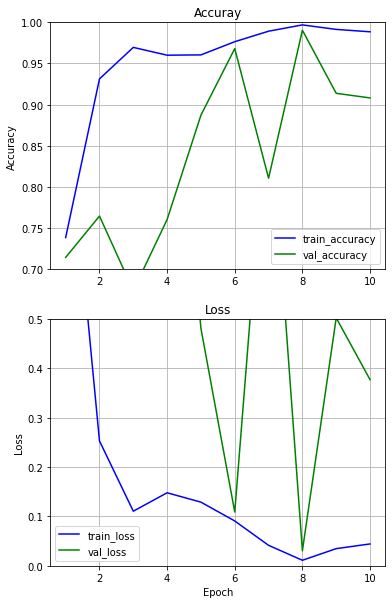

In [ ]:
# 9. accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'g', label='val_accuracy')
plt.ylim([0.7,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.plot(epochs, history.history['val_loss'], 'g', label='val_loss')
plt.ylim([0,0.5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

> ### Training 이후

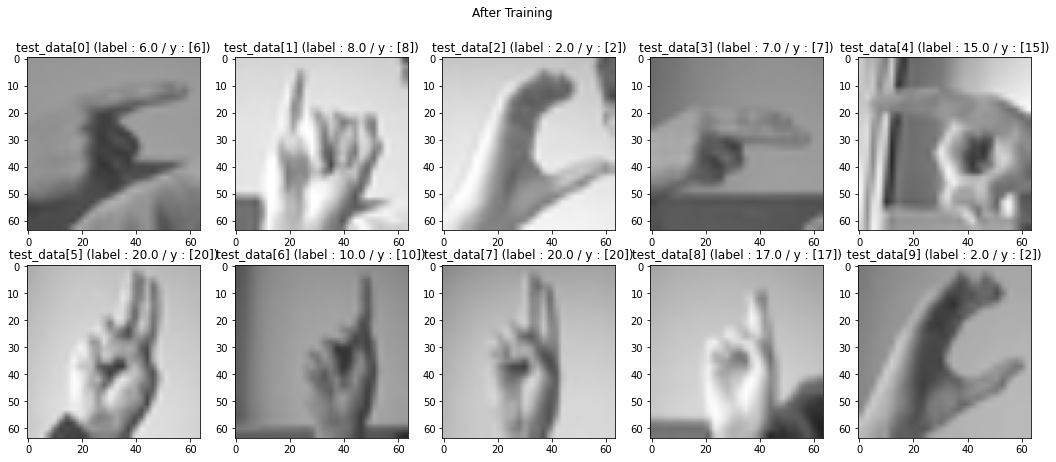

In [ ]:
# 10. 학습 후 상황 그리기
y_out = model.predict(test_data[:10])
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)